In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Importing data set

df=pd.read_csv('C:/Users/Subhadip/Desktop/Great Learning/Python for Data Science/Project/austo_automobile.csv')


In [2]:
#Checking the shape of the data

print("There are",df.shape[0],"rows and",df.shape[1],"columns.")

There are 1581 rows and 14 columns.


In [3]:
#Checking the data types of the columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


In [4]:
#Check for missing values in the data

df.isnull().sum()

Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64

In [9]:
#Check for duplicate rows in the data

df.duplicated().sum()

0

In [11]:
#Replacing blank Gender value with nan
df['Gender'] = df['Gender'].replace([''], np.nan)

In [13]:
df['Gender'].unique()

array(['Male', 'Femal', 'Female', nan, 'Femle'], dtype=object)

In [15]:
# Fixing spelling typos in Gender column

df['Gender'] = df['Gender'].replace(['Femal','Femle'], 'Female')

In [17]:
#Checking for the rows where partner salary is blank but partner working status is Yes

df[df["Partner_salary"].isnull()==True].groupby("Partner_working").size()

Partner_working
No     90
Yes    16
dtype: int64

In [19]:
#Updating Partner salary with 0 where partner is not working
df.loc[df['Partner_working']=='No', 'Partner_salary']=0

In [21]:
# Updating missing partner_salary values
df['Partner_salary']=df['Partner_salary'].fillna(df['Total_salary']-df['Salary'])


In [23]:
#Checking Updated Partner salary column
df[df['Partner_salary'].isnull()==True].shape


(0, 14)

In [25]:
#list of each categorical column
cat_cols =  ['Gender', 'Profession', 'Marital_status', 'Education','Personal_loan','House_loan','Partner_working','Make']

for column in cat_cols:
    print(f"{column}: {df[column].unique()}")

Gender: ['Male' 'Female' nan]
Profession: ['Business' 'Salaried']
Marital_status: ['Married' 'Single']
Education: ['Post Graduate' 'Graduate']
Personal_loan: ['No' 'Yes']
House_loan: ['No' 'Yes']
Partner_working: ['Yes' 'No']
Make: ['SUV' 'Sedan' 'Hatchback']


In [27]:

# Printing the percentage of unique categorical levels in each column
for column in cat_cols:
    print(df[column].value_counts(normalize=True,dropna=False))
    print("-" * 50)

Gender
Male      0.758381
Female    0.208096
NaN       0.033523
Name: proportion, dtype: float64
--------------------------------------------------
Profession
Salaried    0.56673
Business    0.43327
Name: proportion, dtype: float64
--------------------------------------------------
Marital_status
Married    0.912713
Single     0.087287
Name: proportion, dtype: float64
--------------------------------------------------
Education
Post Graduate    0.623023
Graduate         0.376977
Name: proportion, dtype: float64
--------------------------------------------------
Personal_loan
Yes    0.500949
No     0.499051
Name: proportion, dtype: float64
--------------------------------------------------
House_loan
No     0.666667
Yes    0.333333
Name: proportion, dtype: float64
--------------------------------------------------
Partner_working
Yes    0.54902
No     0.45098
Name: proportion, dtype: float64
--------------------------------------------------
Make
Sedan        0.444023
Hatchback    0.368

In [29]:
# Printing the count of unique categorical levels in each column
for column in cat_cols:
    print(df[column].value_counts(dropna=False))
    print("-" * 50)

Gender
Male      1199
Female     329
NaN         53
Name: count, dtype: int64
--------------------------------------------------
Profession
Salaried    896
Business    685
Name: count, dtype: int64
--------------------------------------------------
Marital_status
Married    1443
Single      138
Name: count, dtype: int64
--------------------------------------------------
Education
Post Graduate    985
Graduate         596
Name: count, dtype: int64
--------------------------------------------------
Personal_loan
Yes    792
No     789
Name: count, dtype: int64
--------------------------------------------------
House_loan
No     1054
Yes     527
Name: count, dtype: int64
--------------------------------------------------
Partner_working
Yes    868
No     713
Name: count, dtype: int64
--------------------------------------------------
Make
Sedan        702
Hatchback    582
SUV          297
Name: count, dtype: int64
--------------------------------------------------


In [31]:
#checking the statistical summary of the data

df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1581.0,19233.776091,19670.391171,0.0,0.0,25100.0,38100.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


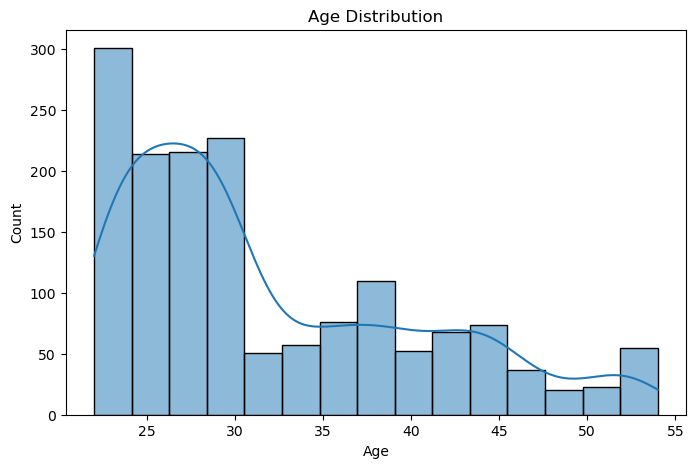

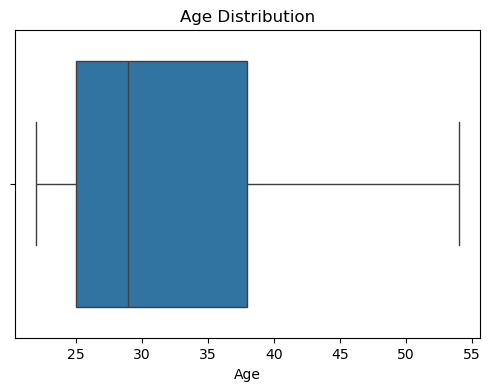

In [33]:
#Univariate Analysis
#Exploring individual variables (both categorical and numerical), highlighting any findings or outliers in the data
#Age Uni_Analysis
plt.figure(figsize=(8, 5))
plt.title("Age Distribution")
sns.histplot(data=df,x='Age',kde=True)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Age Distribution")
sns.boxplot(data=df,x='Age')
plt.show()


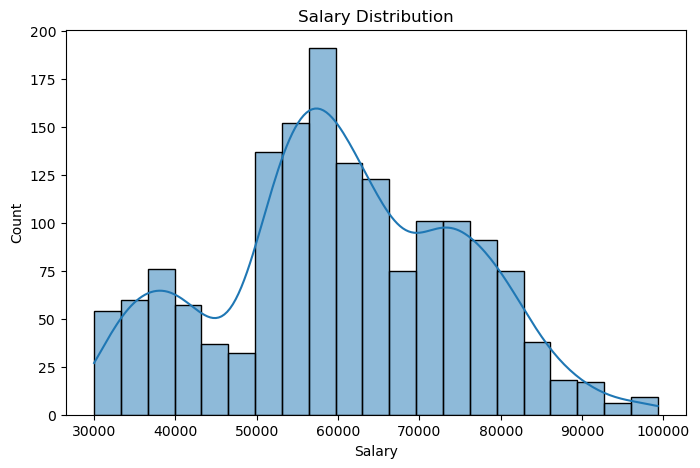

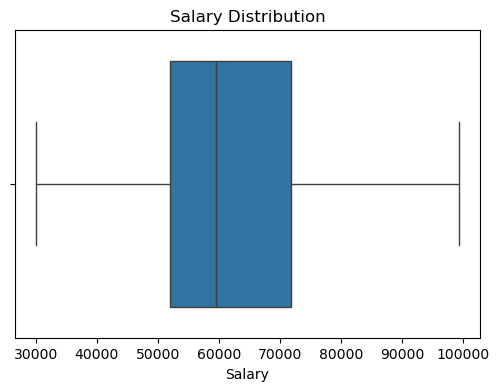

In [34]:
#Salary Uni_Analysis

plt.figure(figsize=(8, 5))
plt.title("Salary Distribution")
sns.histplot(data=df,x='Salary',kde=True)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Salary Distribution")
sns.boxplot(data=df,x='Salary')
plt.show()



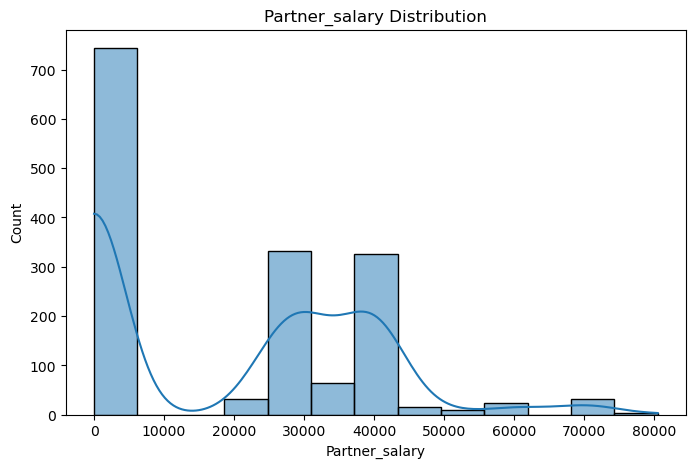

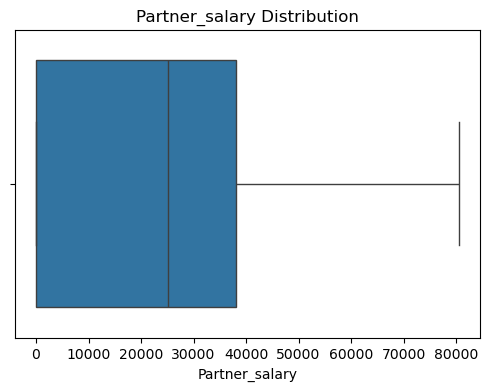

In [35]:
#Partner_salary Uni_Analysis

plt.figure(figsize=(8, 5))
plt.title("Partner_salary Distribution")
sns.histplot(data=df,x='Partner_salary',kde=True)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Partner_salary Distribution")
sns.boxplot(data=df,x='Partner_salary')
plt.show()

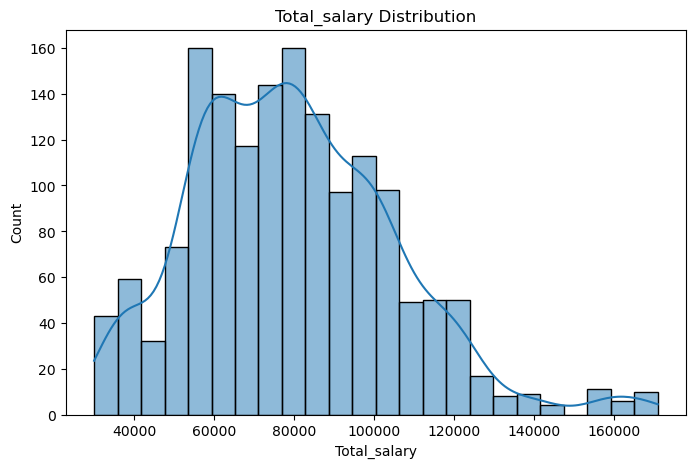

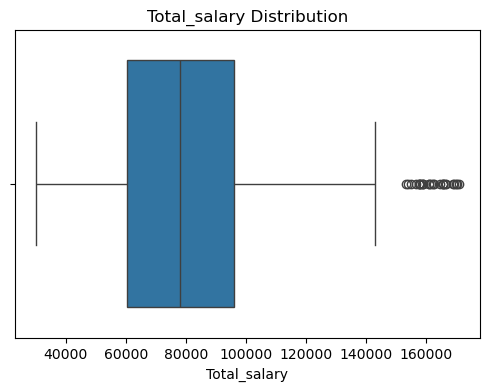

In [37]:
#Total_salary Uni_Analysis

plt.figure(figsize=(8, 5))
plt.title("Total_salary Distribution")
sns.histplot(data=df,x='Total_salary',kde=True)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Total_salary Distribution")
sns.boxplot(data=df,x='Total_salary')
plt.show()

In [39]:
df.loc[df["Total_salary"]>148000]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Female,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
17,49,Female,Salaried,Married,Post Graduate,4,No,No,Yes,95100,70600.0,165700,64000,SUV
18,49,Female,Business,Married,Post Graduate,3,No,No,Yes,92600,70300.0,162900,58000,SUV
19,49,Male,Salaried,Married,Post Graduate,3,Yes,No,Yes,98400,60600.0,159000,54000,SUV
29,46,Female,Salaried,Married,Post Graduate,2,No,No,Yes,98300,70700.0,169000,61000,SUV
30,46,Male,Salaried,Married,Post Graduate,4,No,No,Yes,94900,70700.0,165600,67000,SUV
31,46,Male,Business,Married,Graduate,2,Yes,No,Yes,91100,70000.0,161100,66000,SUV
41,53,Female,Salaried,Married,Post Graduate,4,No,No,Yes,96600,70300.0,166900,66000,SUV


In [41]:
df.loc[df["Total_salary"]>148000].shape

(27, 14)

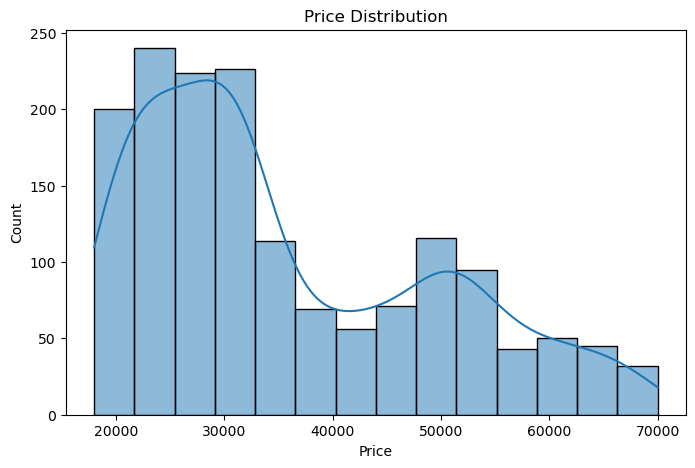

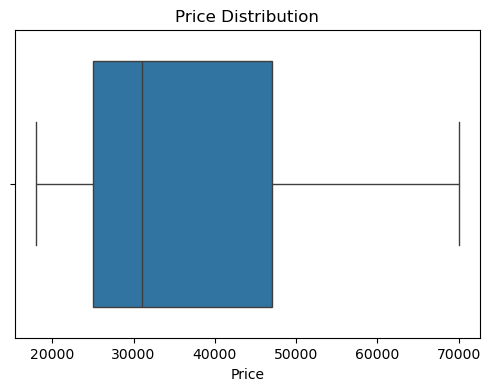

In [45]:
#Price Uni_Analysis

plt.figure(figsize=(8, 5))
plt.title("Price Distribution")
sns.histplot(data=df,x='Price',kde=True)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Price Distribution")
sns.boxplot(data=df,x='Price')
plt.show()

C:\Users\Subhadip\AppData\Local\Temp\ipykernel_11756\4124043570.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Gender',palette='Set2')


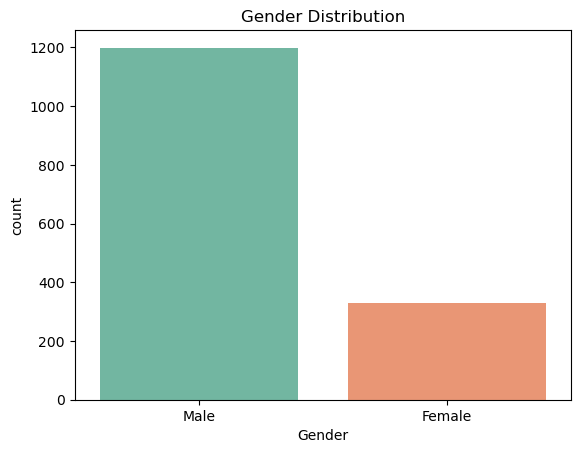

In [47]:
#Gender Uni_Analysis
sns.countplot(data=df,x='Gender',palette='Set2')
plt.title("Gender Distribution")
plt.show()

C:\Users\Subhadip\AppData\Local\Temp\ipykernel_11756\1634271287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Profession',palette='Set2')


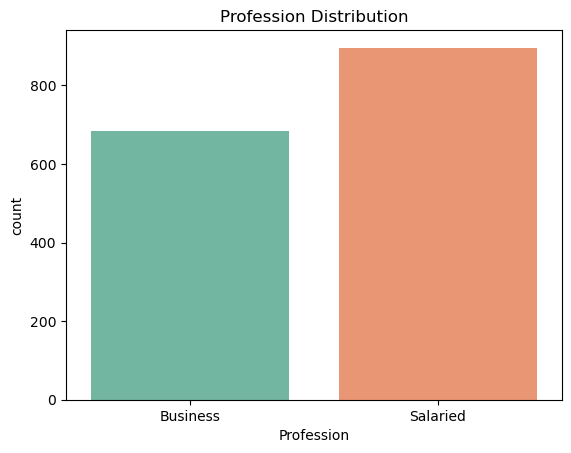

In [49]:
#Profession Uni_Analysis
sns.countplot(data=df,x='Profession',palette='Set2')
plt.title("Profession Distribution")
plt.show()

C:\Users\Subhadip\AppData\Local\Temp\ipykernel_11756\3126784802.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Marital_status',palette='Set2')


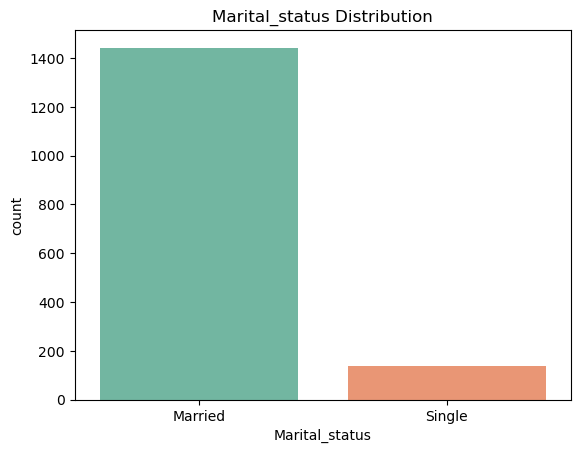

In [51]:
#Marital_status Uni_Analysis
sns.countplot(data=df,x='Marital_status',palette='Set2')
plt.title("Marital_status Distribution")
plt.show()

C:\Users\Subhadip\AppData\Local\Temp\ipykernel_11756\1820373771.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Education',palette='Set2')


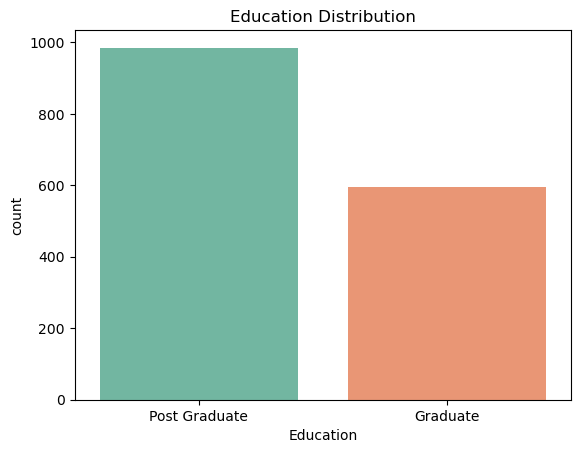

In [53]:
#Education Uni_Analysis
sns.countplot(data=df,x='Education',palette='Set2')
plt.title("Education Distribution")
plt.show()

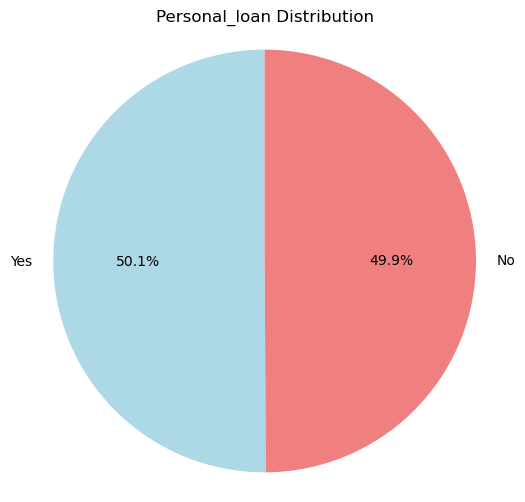

In [61]:
#Personal_loan Uni_Analysis

Personal_loan_counts = df['Personal_loan'].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(Personal_loan_counts, 
        labels=Personal_loan_counts.index, 
        autopct='%1.1f%%',      
        startangle=90,          
        colors=['lightblue', 'lightcoral', 'lightgreen'])

plt.title('Personal_loan Distribution')
plt.axis('equal')
plt.show()

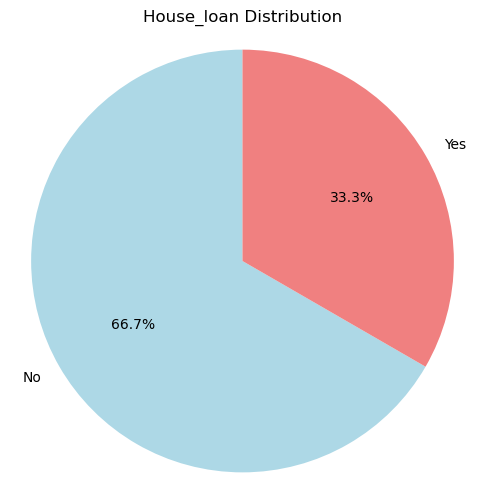

In [63]:
#House_loan Uni_Analysis

House_loan_counts = df['House_loan'].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(House_loan_counts, 
        labels=House_loan_counts.index, 
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightblue', 'lightcoral', 'lightgreen'])

plt.title('House_loan Distribution')
plt.axis('equal')
plt.show()

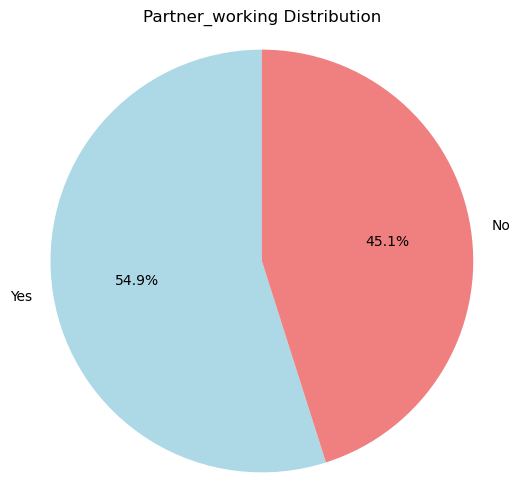

In [65]:
#Partner_working Uni_Analysis

Partner_working_counts = df['Partner_working'].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(Partner_working_counts, 
        labels=Partner_working_counts.index, 
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightblue', 'lightcoral', 'lightgreen'])

plt.title('Partner_working Distribution')
plt.axis('equal')
plt.show()

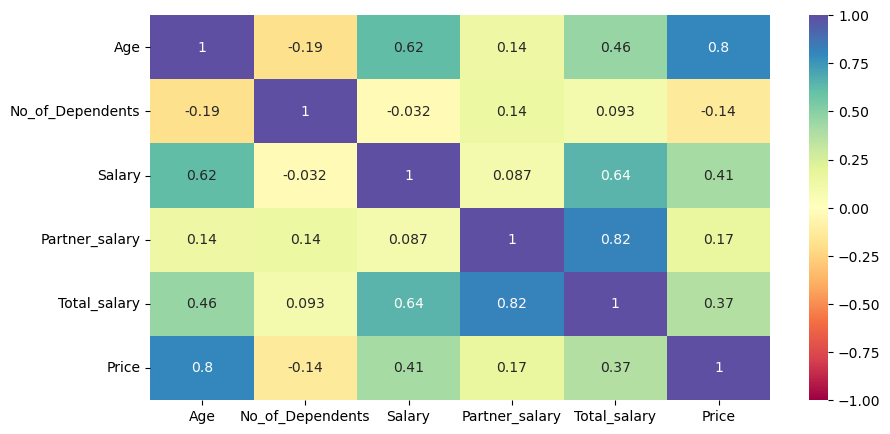

In [67]:
#Bivariate Analysis
##Explore all the numerical variables and check their association with each other

N_df=df.select_dtypes(include='number')

plt.figure(figsize=(10,5))
sns.heatmap(N_df.corr(),
 annot=True, cmap='Spectral', vmin =-1, vmax=1)
plt.show()

In [72]:
 correlation_matrix = N_df.corr()
 correlation_matrix

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
Age,1.000000,-0.189614,0.616899,0.135702,0.458869,0.797831
No_of_Dependents,-0.189614,1.000000,-0.031746,0.144320,0.092890,-0.135839
Salary,0.616899,-0.031746,1.000000,0.087155,0.641560,0.409920
Partner_salary,0.135702,0.144320,0.087155,1.000000,0.820069,0.171875
Total_salary,0.458869,0.092890,0.641560,0.820069,1.000000,0.367823
Price,0.797831,-0.135839,0.409920,0.171875,0.367823,1.000000


In [ ]:
#Pair Plot

sns.pairplot(data=df, vars=['Age', 'No_of_Dependents', 'Salary', 'Partner_salary','Total_salary','Price'],diag_kind="kde", corner=True);

<Axes: xlabel='Gender', ylabel='count'>

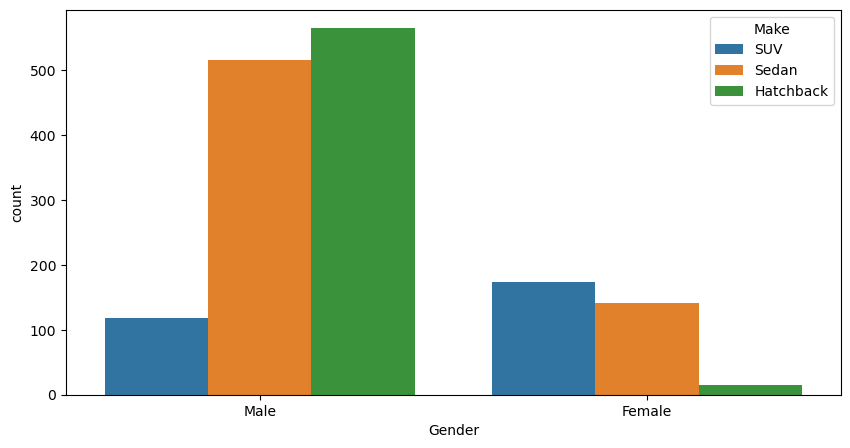

In [87]:
#Now see if men prefer SUVs more than women
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Gender',hue='Make')

In [89]:
#Likelihood of a salaried person buying a Sedan

salaried_df = df[df['Profession'] == 'Salaried']   #Filtering out salaried people
sedan_count = salaried_df[salaried_df['Make'] == 'Sedan'].shape[0]   # Number of salaried people who bought Sedan
total_salaried = salaried_df.shape[0]   # Number of Total salaried people

likelihood = (sedan_count / total_salaried)*100

print("Likelihood of a salaried person buying a Sedan is",likelihood,"%")

Likelihood of a salaried person buying a Sedan is 44.19642857142857 %


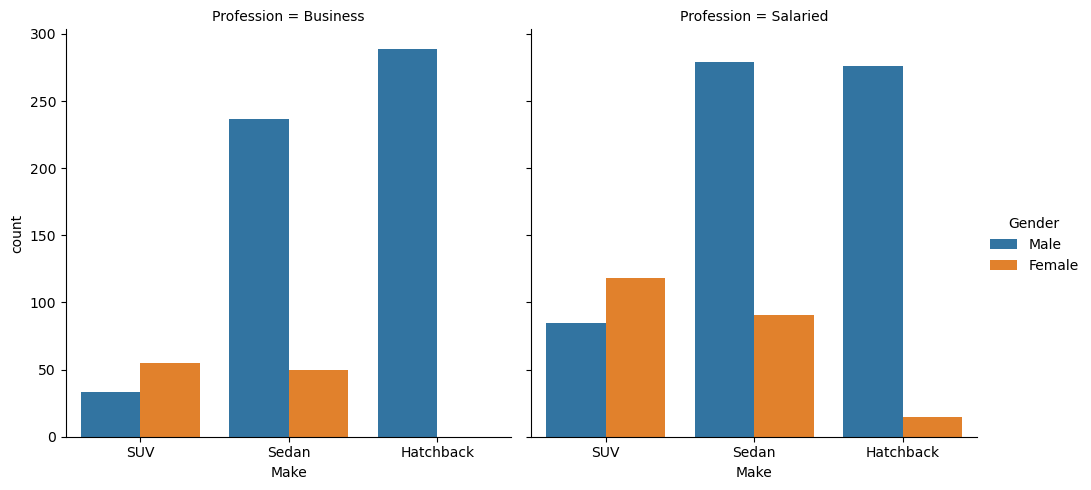

In [91]:
#Checking the Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale

sns.catplot(data=df,col='Profession',x='Make',hue='Gender',kind='count')

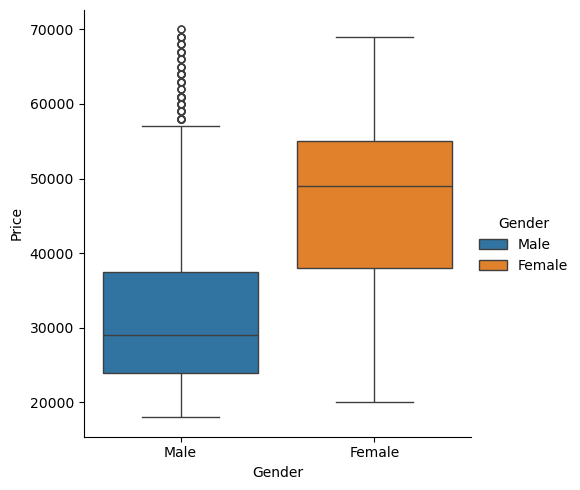

In [93]:
#Investigating the difference in automobile purchasing between genders

sns.catplot(data=df, x="Gender", y="Price", hue="Gender", kind='box')

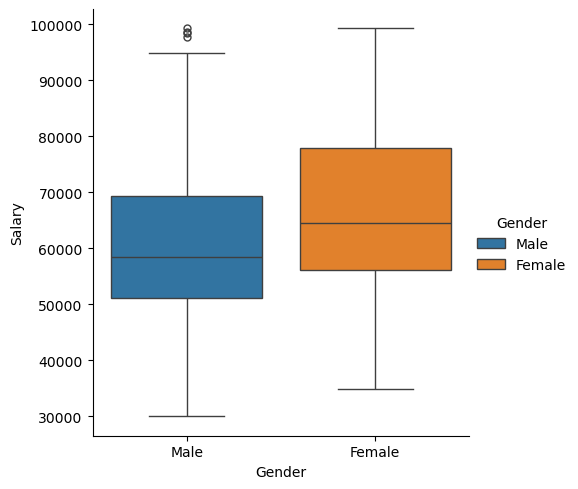

In [99]:
sns.catplot(data=df, x="Gender", y="Salary", hue="Gender", kind='box')

In [109]:
df.loc[df['Price'] > 57000].sort_values(by=['Salary', 'Partner_salary'],ascending=True).head(15)


,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
175,44,Male,Salaried,Married,Graduate,3,No,No,Yes,46900,70600.0,117500,59000,SUV
454,36,Male,Salaried,Married,Graduate,2,Yes,No,Yes,47000,40400.0,87400,61000,SUV
473,36,Female,Salaried,Single,Graduate,2,Yes,No,No,47300,0.0,47300,66000,SUV
511,35,Male,Salaried,Married,Graduate,3,No,No,No,48200,0.0,48200,58000,SUV
328,40,Male,Business,Married,Graduate,2,No,No,No,48300,0.0,48300,64000,SUV
369,39,Female,Salaried,Married,Graduate,2,No,No,No,48600,0.0,48600,63000,SUV
172,44,Female,Business,Married,Graduate,4,No,No,Yes,48600,70800.0,119400,67000,SUV
374,38,Female,Salaried,Married,Graduate,4,Yes,No,Yes,49700,70500.0,120200,64000,SUV
246,42,Female,Salaried,Married,Graduate,4,No,No,Yes,50100,70400.0,120500,65000,SUV
193,44,Male,Salaried,Married,Graduate,3,No,No,Yes,50300,28100.0,78400,60000,SUV


<Axes: xlabel='Make', ylabel='Price'>

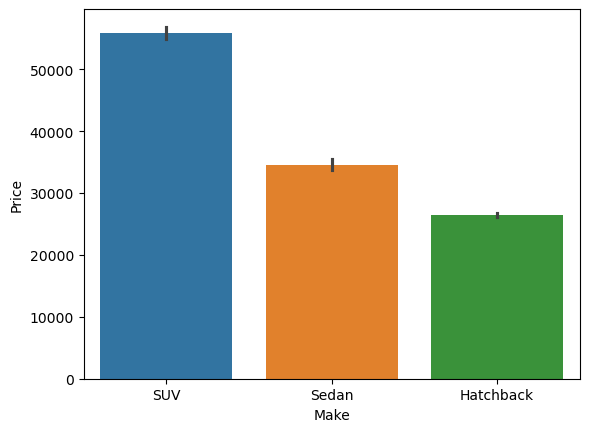

In [111]:
 #checking the price structure for different types of Make
 sns.barplot(data=df,x='Make',y='Price',hue='Make')


<Axes: xlabel='Make', ylabel='Price'>

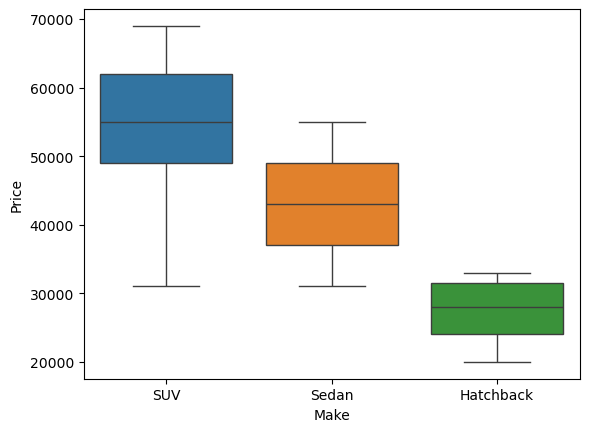

In [119]:
 ##creating a data frame for Female
 df_female = df.loc[df['Gender']=='Female']
 ## Checking the price structure where Females are focusing
 sns.boxplot(data=df_female, x='Make',y='Price',hue='Make')

In [121]:
df_female.groupby('Make')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
Hatchback,15.0,27466.666667,4240.395310,20000.0,24000.0,28000.0,31500.0,33000.0
SUV,173.0,53479.768786,10378.079311,31000.0,49000.0,55000.0,62000.0,69000.0
Sedan,141.0,42773.049645,7248.023173,31000.0,37000.0,43000.0,49000.0,55000.0


<Axes: xlabel='Make', ylabel='Price'>

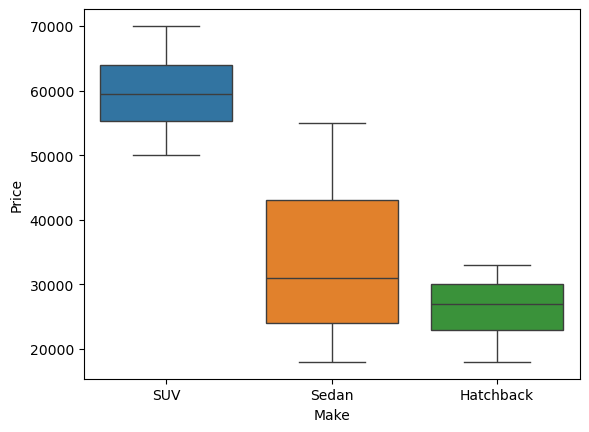

In [123]:
 ##creating a data frame for male
 df_male = df.loc[df['Gender']=='Male']
 ## Checking the price structure where Females are focusing
 sns.boxplot(data=df_male, x='Make',y='Price',hue='Make')

In [125]:
df_male.groupby('Make')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
Hatchback,565.0,26476.106195,4273.646655,18000.0,23000.0,27000.0,30000.0,33000.0
SUV,118.0,59584.745763,5673.941441,50000.0,55250.0,59500.0,64000.0,70000.0
Sedan,516.0,33639.534884,10752.371921,18000.0,24000.0,31000.0,43000.0,55000.0


,count,mean,std,min,25%,50%,75%,max
Personal_loan,,,,,,,,
No,789.0,36742.712294,14534.344526,18000.0,25000.0,32000.0,49000.0,70000.0
Yes,792.0,34457.070707,12578.780338,18000.0,24000.0,31000.0,45000.0,70000.0


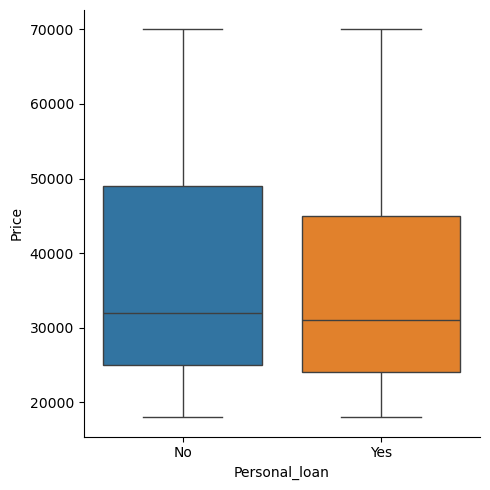

In [129]:
#Analyzing the impact of personal loan on purchasing automobiles

sns.catplot(data=df, x="Personal_loan", y="Price", hue="Personal_loan", kind='box')
df.groupby('Personal_loan')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Partner_working,,,,,,,,
No,713.0,36000.000000,13817.734086,18000.0,25000.0,31000.0,48000.0,70000.0
Yes,868.0,35267.281106,13479.532555,18000.0,24000.0,31000.0,46000.0,70000.0


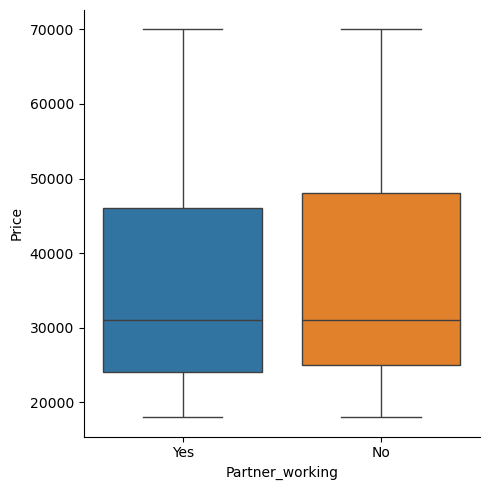

In [131]:
#Analyzing impact of having a working partner on the purchase of higher-priced cars

sns.catplot(data=df, x="Partner_working", y="Price", hue="Partner_working", kind='box')
df.groupby('Partner_working')['Price'].describe()

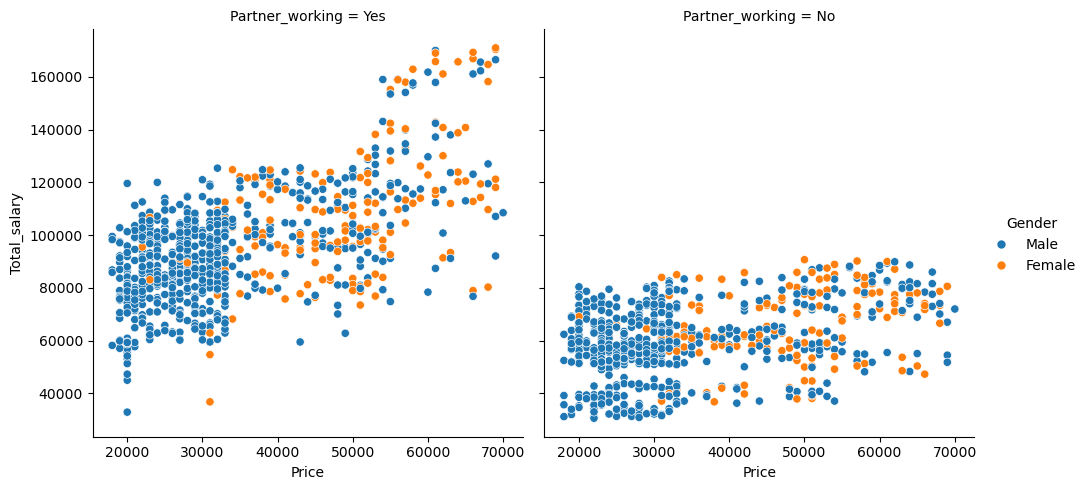

In [141]:
sns.relplot(data=df,x='Price',y='Total_salary',hue='Gender',col='Partner_working',kind='scatter')
plt.show()

<Axes: xlabel='Education', ylabel='count'>

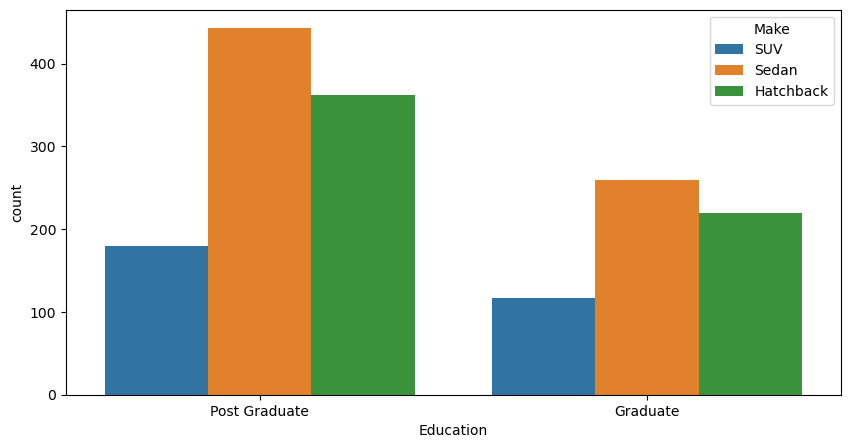

In [143]:
#Analyzing impact of having a Higher education on the capacity of purchasing a car

plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Education',hue='Make')